In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import scipy.stats as st
import numpy as np
# import statannotations
import scipy
# import statsmodels.api as sm
from pathlib import Path
from collections import defaultdict

# Read in samples and OD data

In [2]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'
figure_folder = repo_folder / 'figures'/'3_big_screen'
figure_folder.mkdir(exist_ok=True, parents=True)

In [3]:
samples_fn = metabolomics_folder / 'A_samples.csv'
samples_df = pd.read_csv(samples_fn, index_col=0)

In [4]:
od_fn = metabolomics_folder / 'B_od_data.csv'
od_df = pd.read_csv(od_fn, index_col=0)

## Plot growth curve of a given strain

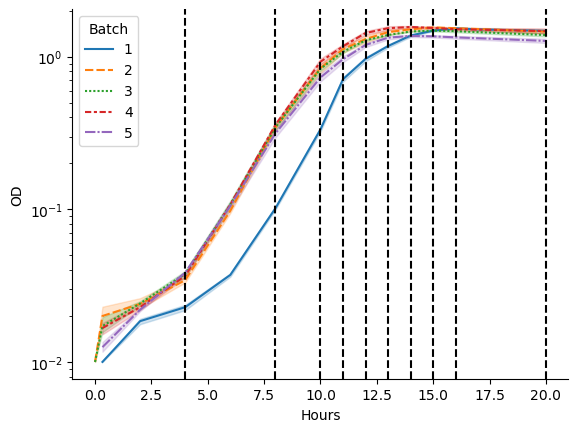

In [5]:
s = 'WT'
ax = sns.lineplot(data=od_df.loc[od_df.Strain==s], x = 'Hours', y = 'OD', hue = 'Batch',
                 style = 'Batch',  legend=True, palette='tab10')#estimator=None, units='Parallel',
measured_timepoints = ~od_df.Timepoint.isna()
sampling_timepoints = od_df.loc[(od_df.Strain==s)&measured_timepoints].Hours.unique()
for t in sampling_timepoints:
    ax.axvline(t, ls = '--', c = 'k')
plt.yscale('log')
sns.despine()

In [6]:
strains = sorted([x for x in od_df['Strain'].unique()])

# Separate strains into KO strains that are referenced against the WT and the others strains which are referenced against E. coli MG1655


In [7]:
all_strains = samples_df['Strain'].unique()

In [8]:
od_df.Batch.unique()

array([1, 2, 3, 4, 5])

## Plot KO strains and KEIO WT

0 WT 1
1 mscS 1
2 ompC 1
3 ompF 1
4 oppA 1
5 punC 1
6 rhtA 1
7 satP 1
8 sstT 1
9 tsx 1
10 ybjE 1
11 yddG 1
12 yeaS 1
13 yedA 1
14 ygaZ 1
15 WT 2
16 acrB 2
17 actP 2
18 adeP 2
19 argO 2
20 aroP 2
21 brnQ 2
22 codB 2
23 gltJ 2
24 lysP 2
25 nagE 2
26 ptsG 2
27 putP 2
28 setA 2
29 yhjE 2
30 WT 3
31 artQ 3
32 cycA 3
33 focA 3
34 fruA 3
35 gadC 3
36 glnP 3
37 glpF 3
38 gltP 3
39 mscL 3
40 nupC 3
41 proP 3
42 rbsC 3
43 sdaC 3
44 znuB 3
45 WT 4
46 cstA 4
47 dctA 4
48 dcuA 4
49 dppB 4
50 emrB 4
51 galP 4
52 gltS 4
53 mtr 4
54 nupG 4
55 pheP 4
56 rhtC 4
57 tdcC 4
58 ugpA 4
59 uhpT 4
60 WT 5
61 ansP 5
62 eamA 5
63 glpT 5
64 hisQ 5
65 kgtP 5
66 livH 5
67 manY 5
68 metI 5
69 rhtB 5
70 tolC 5
71 yahN 5


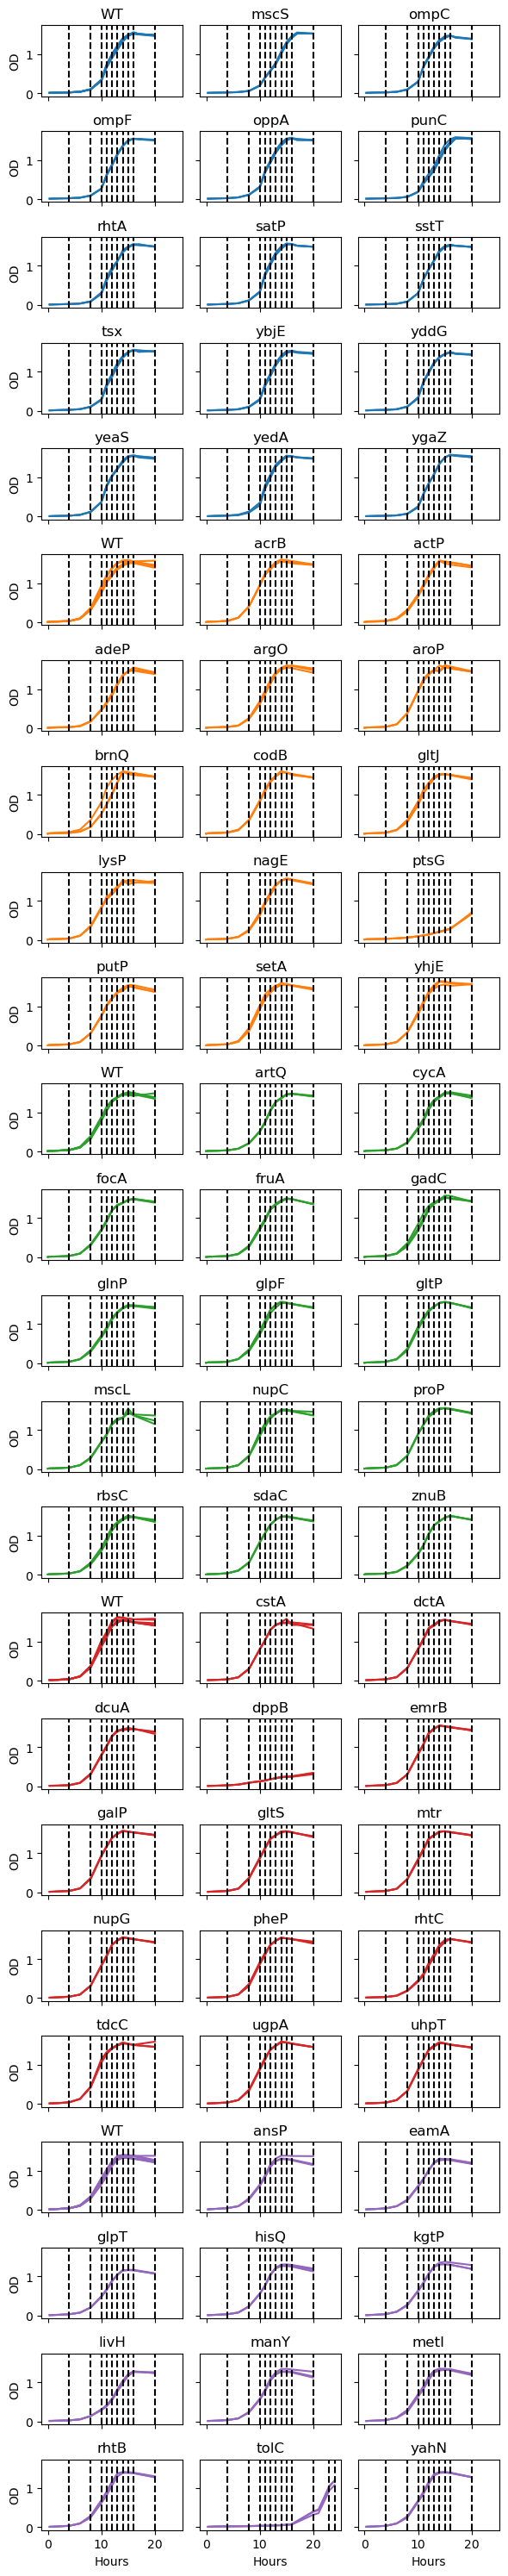

In [11]:
fig, axes = plt.subplots(24,3, figsize = (6, 30), sharex=True, sharey=True)
axes = axes.flatten()
measured_timepoints = ~od_df.Timepoint.isna()
od_df.sort_values(by = ['Batch', 'Strain'], inplace=True)
batches = od_df.Batch.unique()
i = 0
batch_to_color = {b: c for b, c in zip(batches, sns.color_palette('tab10', len(batches)))}
for batch in batches:
    odb = od_df.loc[od_df.Batch==batch]
    bstrains = odb.Strain.unique()
    for _, s in enumerate(bstrains):
        print(i,s, batch)
        # print(od_df.loc[od_df.Strain==s, ['Hours', 'OD']])
        sns.lineplot(data=odb.loc[odb.Strain==s], x = 'Hours', y = 'OD', c = batch_to_color[batch],
                    ax = axes[i], estimator=None, units='Parallel', legend=None)
        # g =sns.relplot(data = od_df, x = 'Hours', y = 'OD', col = 'Strain')
        axes[i].set_title(s)
        
        sampling_timepoints = od_df.loc[(od_df.Strain==s)&measured_timepoints].Hours.unique()
        for t in sampling_timepoints:
            axes[i].axvline(t, ls = '--', c = 'k')
        i+=1
# axes[i].set_yscale('log')
# for
# axes[-1].remove()
plt.tight_layout()

plt.savefig(figure_folder / 'KEIO_growth_curves_with_sample_timepoints_log.png', dpi = 400)
plt.savefig(figure_folder / 'KEIO_growth_curves_with_sample_timepoints_log.pdf')

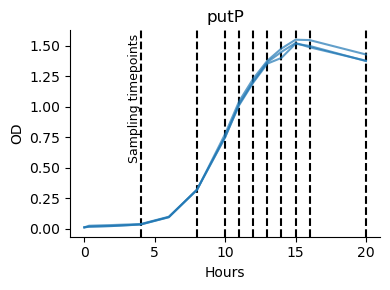

In [12]:
fig, ax = plt.subplots(1, figsize = (4, 3), sharex=True, sharey=True)
measured_timepoints = ~od_df.Timepoint.isna()
s = 'putP'
# print(od_df.loc[od_df.Strain==s, ['Hours', 'OD']])
sns.lineplot(data=od_df.loc[od_df.Strain==s], x = 'Hours', y = 'OD', hue = 'Medium',
                style = 'Batch', ax = ax, estimator=None, units='Parallel', legend=None, 
                alpha = 0.7,
                zorder = 100)
# g =sns.relplot(data = od_df, x = 'Hours', y = 'OD', col = 'Strain')
ax.set_title(s)
sampling_timepoints = od_df.loc[(od_df.Strain==s)&measured_timepoints].Hours.unique()
for t in sampling_timepoints:
    ax.axvline(t, ls = '--', c = 'k')

ax.annotate('Sampling timepoints', xy=(sampling_timepoints[0], 1.6),
            ha = 'right', va = 'top',
            rotation = 90, 
            fontsize=9,
            )
# axes[i].set_yscale('log')
# for
# axes[-1].remove()
plt.tight_layout()
sns.despine()

plt.savefig(figure_folder / 'putP_growth_curve_with_sample_timepoints_log.png', dpi = 400)
plt.savefig(figure_folder / 'putP_growth_curve_with_sample_timepoints_log.pdf')

# Plot pairs

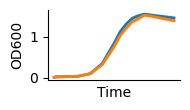

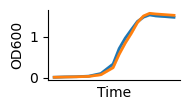

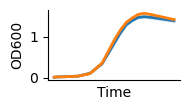

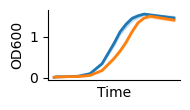

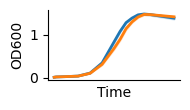

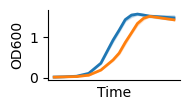

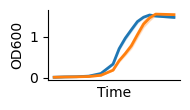

In [13]:
od_pairs = [
    ('WT', 'putP'),
    ('WT', 'ygaZ'),
    ('WT', 'gltP'),
    ('WT', 'adeP'),
    ('WT', 'glnP'),
    ('WT', 'rhtC'),
    ('WT', 'punC'),
]

for strain_pair in od_pairs:
    fig, ax = plt.subplots(1, figsize = (2, 1.2), sharex=True, sharey=True)
    measured_timepoints = ~od_df.Timepoint.isna()
    batch = od_df.loc[od_df.Strain==strain_pair[1], 'Batch'].unique()[0]
    data = od_df.loc[(od_df.Strain.isin(strain_pair))&(od_df['Batch'] == batch)]
        # print(od_df.loc[od_df.Strain==s, ['Hours', 'OD']])
    # sns.lineplot(data=data, x = 'Hours', y = 'OD', hue = 'Strain',
    #                 ax = ax, estimator=None, units='Parallel', legend='full', 
    #                 alpha = 0.7,
    #                 zorder = 100)
    sns.lineplot(data=data, x = 'Hours', y = 'OD', hue = 'Strain',
    ax = ax, 
    alpha = 1,
    lw = 2,
    legend = False,
    zorder = 100)
    # g =sns.relplot(data = od_df, x = 'Hours', y = 'OD', col = 'Strain')
    # ax.set_title(f'Growth curves: {strain_pair[0]} vs {strain_pair[1]}')
    
    sns.despine()
    ax.set_xticks([])        # Removes the ticks
    ax.set_xticklabels([])
    ax.set_ylabel('OD600')
    ax.set_xlabel('Time')
    plt.tight_layout()

    plt.savefig(figure_folder / f'growth_curve_comparison_{"_vs_".join(strain_pair)}.png', dpi = 400, bbox_inches='tight')
    plt.savefig(figure_folder / f'growth_curve_comparison_{"_vs_".join(strain_pair)}.pdf', bbox_inches='tight')

# Find last timepoint in exponential phase

In [14]:
def find_last_hour_before_threshold(od, hours, threshold_od):
    h_peak = 0
    for o, h in zip(od, hours):
        if o>threshold_od:
            return h_peak
        else:
            h_peak = h
    return h_peak
            

In [27]:
max_od = defaultdict(lambda:0)
max_od[(2, 'ptsG', 'M9 20 mM glucose pH 7.4')] = 1.2
max_od[(4, 'dppB', 'M9 20 mM glucose pH 7.4')] = 1.2
max_od[(5, 'tolC', 'M9 20 mM glucose pH 7.4')] = 1.2
max_od[(5, 'tolC', 'M9 20 mM glucose pH 7.4')] = 1.2


In [28]:
batch_tube_to_medium = od_df.set_index(['Batch', 'Tube'])['Medium'].to_dict()

In [29]:
od_df.Batch.unique()

array([2, 3, 5, 1, 4])

In [30]:
set(batch_tube_to_medium.values())

{'M9 20 mM glucose pH 7.4'}

rhtA 1.556 1.4004 ['12C' '12B' '12A'] 14.0
ompF 1.547 1.3922999999999999 ['4A' '4B' '4C'] 14.0
mscS 1.553 1.3977 ['13B' '13C' '13A'] 16.0
sstT 1.538 1.3842 ['14A' '14C' '14B'] 14.0
tsx 1.558 1.4022000000000001 ['1C' '1B' '1A'] 14.0
yddG 1.503 1.3527 ['5A' '5C' '5B'] 14.0
oppA 1.569 1.4121 ['2A' '2C' '2B'] 14.0
WT 1.558 1.4022000000000001 ['0D' '0B' '0C' '0F' '0E' '0A'] 14.0
ompC 1.478 1.3302 ['3A' '3B' '3C'] 14.0
punC 1.581 1.4229 ['11C' '11A' '11B'] 15.0
satP 1.567 1.4102999999999999 ['7A' '7B' '7C'] 14.0
ybjE 1.537 1.3833 ['6A' '6B' '6C'] 14.0
yeaS 1.563 1.4067 ['10A' '10B' '10C'] 14.0
ygaZ 1.577 1.4193 ['9C' '9A' '9B'] 14.0
yedA 1.555 1.3995 ['8A' '8B' '8C'] 14.0
actP 1.581 1.4229 ['4B' '4C' '4A'] 13.0
setA 1.61 1.449 ['8B' '8A' '8C'] 13.0
WT 1.591 1.4319 ['0A' '0B' '0F' '0E' '0D' '0C'] 13.0
yhjE 1.654 1.4886 ['2C' '2B' '2A'] 13.0
codB 1.611 1.4499 ['5A' '5C' '5B'] 13.0
putP 1.549 1.3941 ['14A' '14C' '14B'] 14.0
ptsG 0.697 0.6273 ['12C' '12B' '12A'] 20.0
nagE 1.57 1.413 ['10B' '10A'

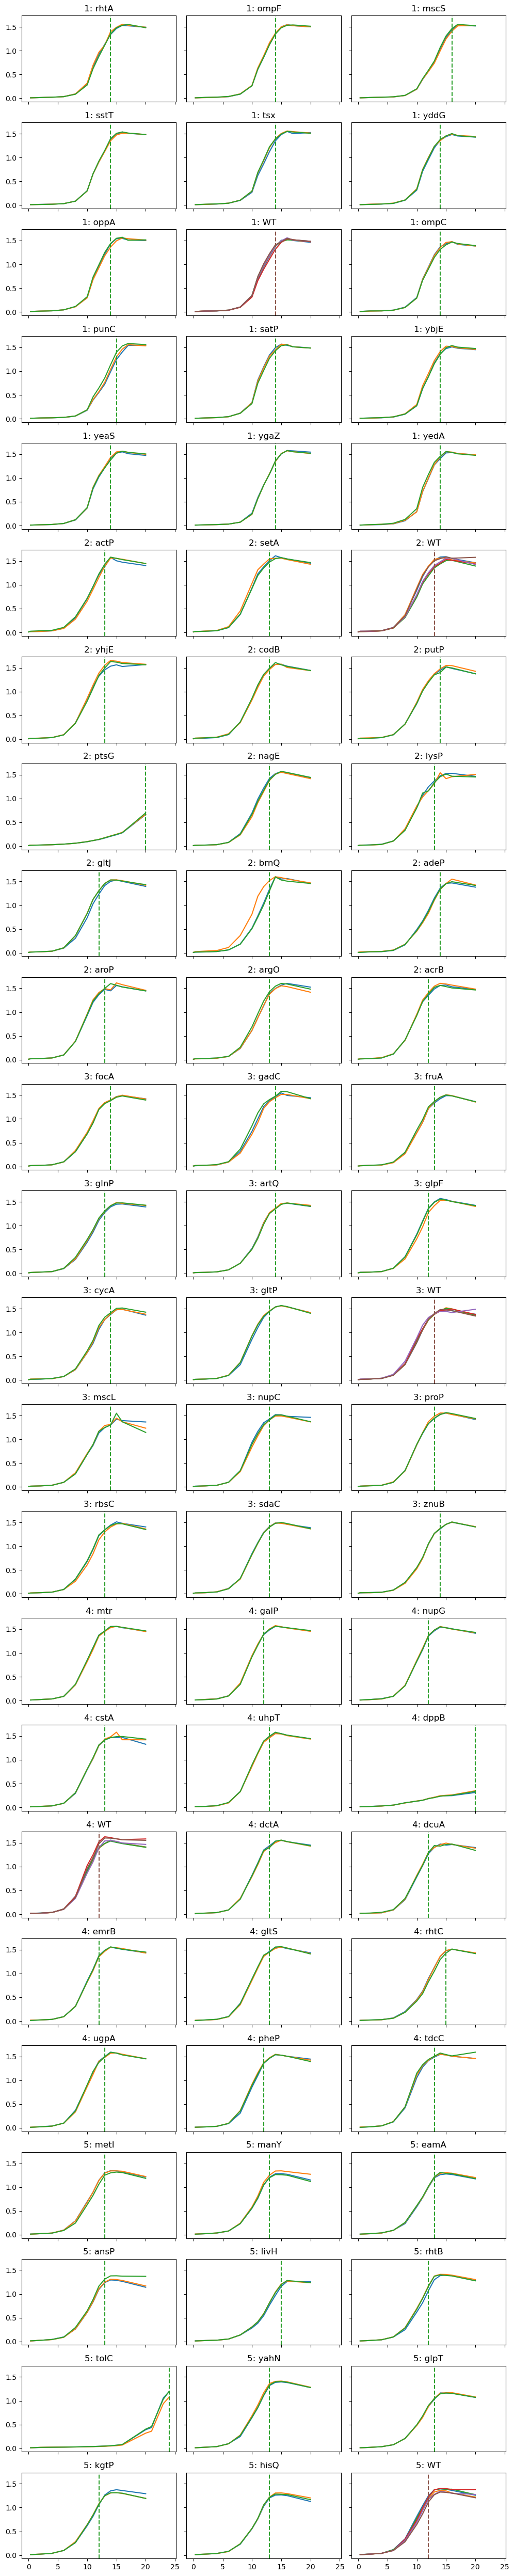

In [32]:
exp_hour_dict = {}
fig, axes = plt.subplots(24, 3, sharex=True, sharey=True, figsize = (10,50))
axes = axes.flatten()
axi = 0
batches = [1,2,3,4,5]
od_df.sort_values(by = 'Hours', inplace=True)
for i, b in enumerate(batches):
    
    odb = od_df.loc[od_df.Batch==b]
    bstrains = odb.Strain.unique()
    for j, strain in enumerate(bstrains):
        dfj = odb.loc[odb.Strain == strain]
        media = dfj.Medium.unique()
        for mi, medium in enumerate(media):
            dfm = dfj.loc[dfj.Medium==medium]
            mtubes = dfm.Tube.unique()
            exp_hours = []
            for k, tube in enumerate(mtubes):
                axes[axi].plot(dfm.loc[dfm.Tube==tube, 'Hours'],dfm.loc[dfm.Tube==tube, 'OD'], c = f'C{k}')
                exp_od = max_od[(b, strain, medium)]
                if '+' in medium:
                    print(b, strain, medium, exp_od)
                if exp_od == 0:
                    exp_od = dfm.loc[dfm.Tube==tube].OD.max()*0.95
                exp_hour = find_last_hour_before_threshold(dfm.loc[dfm.Tube==tube, 'OD'], dfm.loc[dfm.Tube==tube, 'Hours'], exp_od)
                exp_hours.append(exp_hour)
            exp_hour_median = np.median(exp_hour)
            for k, tube in enumerate(mtubes):
                exp_hour_dict[f'{b}-{tube}'] = exp_hour_median
            
            axes[axi].axvline(exp_hour_median, c = f'C{k}', ls = '--')
        axes[axi].set_title(f'{b}: {strain}')
        axi+= 1
        print(strain, dfj.OD.max(), dfj.OD.max()*0.9, mtubes, exp_hour_median)
    # dfi.sort_values(by='Hours', ascending=True, inplace=True)
    # exp_hour = find_last_hour_before_threshold(dfi.OD, dfi.Hours, default_od_threshold_exp_phase)
    
    # print(bt, dfi.Strain.values[0])
    
    # axes[i].plot(dfi.Hours, dfi.OD.astype(float))
    # axes[i].set_title(f'{bt}: {dfi.Strain.values[0]}')
    # axes[i].grid()

plt.tight_layout()
plt.show()

        

In [33]:
exp_hour_dict[('5-19A')] = 20
exp_hour_dict[('5-19B')] = 20
exp_hour_dict[('5-19C')] = 20
exp_hour_dict[('5-20A')] = 20
exp_hour_dict[('5-20B')] = 20
exp_hour_dict[('5-20C')] = 20

# putP
exp_hour_dict[('2-14A')] = 12
exp_hour_dict[('2-14B')] = 12
exp_hour_dict[('2-14C')] = 12

# punC 
exp_hour_dict[('1-11A')] = 15
exp_hour_dict[('1-11B')] = 15
exp_hour_dict[('1-11C')] = 15



In [34]:
od_df['Exp. phase time limit'] = od_df['Batch-Tube'].map(exp_hour_dict)

# Calculate AUC of OD values

In [35]:
# timesteps = len(od_df.Hours.unique())-1
# hours = list(od_df.columns[2:])
auc_data = []
unique_tubes = od_df['Batch-Tube'].unique()
for i, bt in enumerate(unique_tubes):
    dfi = od_df.loc[(od_df['Batch-Tube']==bt)].copy()
    dfi.sort_values(by='Hours', ascending=True, inplace=True)
    
    for h in dfi.Hours:
        if np.isnan(h):
            continue
        hidx = dfi.Hours <= h
        auc = scipy.integrate.simpson(dfi.OD[hidx], x = dfi.Hours[hidx])
        auc_data.append([bt, auc, h])


In [36]:
df_auc = pd.DataFrame(auc_data, columns=['Batch-Tube', 'AUC OD', 'Hours'])
df_auc.head(5)

,Batch-Tube,AUC OD,Hours
0,2-4B,0.000000,0.00
1,2-4B,0.004290,0.33
2,2-4B,0.041125,2.00
3,2-4B,0.093215,4.00
4,2-4B,0.199125,6.00


In [37]:
od_final = od_df.merge(df_auc, left_on = ('Batch-Tube', 'Hours'), right_on = ('Batch-Tube', 'Hours'), how = 'left')

In [38]:
fn_od_auc = od_fn = metabolomics_folder / 'F_od_and_auc.csv'


od_final.to_csv(fn_od_auc)

# Extract growth rates

### Note - might be worth comparing growth rates extracted from platereader data

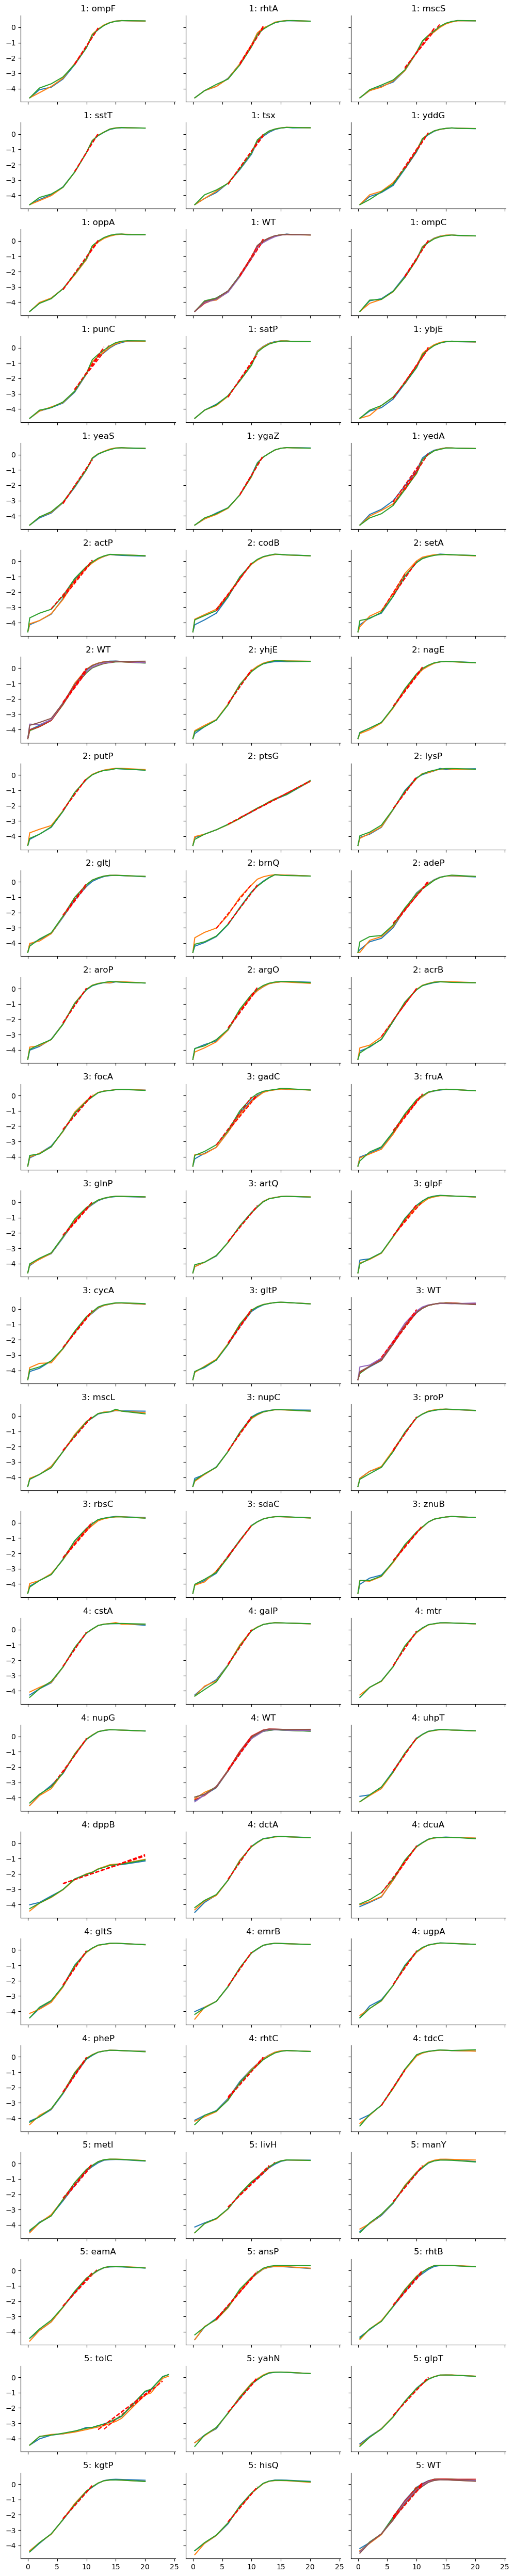

In [40]:
fig, axes = plt.subplots(24, 3, sharex=True, sharey=True, figsize = (10,50))
axes = axes.flatten()
axi = 0
batches = [1,2,3,4,5]
od_df.sort_values(by = 'Hours', inplace=True)
growth_rates = []
for i, b in enumerate(batches):
    odb = od_df.loc[od_df.Batch==b]
    bstrains = [x for x in odb.Strain.unique() if x in all_strains]
    for j, strain in enumerate(bstrains):
        dfj = odb.loc[odb.Strain == strain]
        media = dfj.Medium.unique()
        for mi, medium in enumerate(media):
            dfm = dfj.loc[dfj.Medium==medium]
            mtubes = dfm.Tube.unique()
            exp_hours = []
            for k, tube in enumerate(mtubes):
                y = dfm.loc[dfm.Tube==tube, 'OD']
                x = dfm.loc[dfm.Tube==tube, 'Hours']
                ln_y = np.log(y.replace(0, np.nan)).dropna()
                axes[axi].plot(x, ln_y, c = f'C{k}')
                exp_hour_median = exp_hour_dict[f'{b}-{tube}']
                fit_idx = (y<1)&(y>=0.04)#= exp_hour_median
                fit = np.polyfit(x[fit_idx], ln_y[fit_idx], 1)
                yfit = np.polyval(fit, x[fit_idx])
                axes[axi].plot(x[fit_idx], yfit, c = f'r', ls = '--')
                growth_rates.append([b, tube, strain, medium, fit[0], exp_hour_median])

        axes[axi].set_title(f'{b}: {strain}')
        axi+= 1
sns.despine()
plt.tight_layout()
# plt.show()


In [41]:
df_growth_rates = pd.DataFrame(growth_rates, columns=['Batch', 'Tube', 'Strain', 'Medium', 'Growth rate (1/h)', 'Exp. phase time limit (h)'])

In [42]:
df_growth_rates.to_csv(metabolomics_folder/'C_growth_rates_in_tubes.csv')

In [48]:
df_growth_rates.loc[df_growth_rates.Strain=='dppB']

,Batch,Tube,Strain,Medium,Growth rate (1/h),Exp. phase time limit (h)
165,4,2A,dppB,M9 20 mM glucose pH 7.4,0.127572,20.0
166,4,2B,dppB,M9 20 mM glucose pH 7.4,0.136180,20.0
167,4,2C,dppB,M9 20 mM glucose pH 7.4,0.130857,20.0


In [43]:
mean_gr = df_growth_rates.groupby(['Strain', 'Batch']).agg({'Growth rate (1/h)': ('mean', 'std')}).reset_index()
mean_gr.columns = ['Strain', 'Batch', 'Mean growth rate (1/h)', 'SD growth rate (1/h)'] 

# Add a column with the mean WT growth rate per batch
wt_mean_gr = mean_gr.loc[mean_gr['Strain'] == 'WT', ['Batch', 'Mean growth rate (1/h)']].set_index('Batch')
wt_mean_gr = wt_mean_gr.rename(columns={'Mean growth rate (1/h)': 'WT_mean_gr'})

# Merge with mean_gr to get WT mean for each batch
mean_gr = mean_gr.merge(wt_mean_gr, on='Batch', how='left')

# Divide each growth rate by the mean WT growth rate in that batch
mean_gr['Rel. growth rate'] = mean_gr['Mean growth rate (1/h)'] / mean_gr['WT_mean_gr']



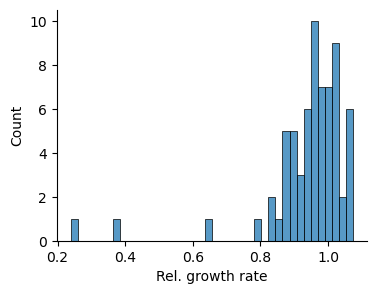

In [45]:
gr_idx = ~mean_gr.Strain.str.contains('WT')
fig, ax = plt.subplots(1, figsize = (4, 3), sharex=True, sharey=True)
sns.histplot(data=mean_gr.loc[gr_idx], x='Rel. growth rate', bins=40, ax = ax)
sns.despine()
